In [1]:

import torch
import scanpy as sc
import numpy as np
import os
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
torch.tensor(0).to('cuda')

tensor(0, device='cuda:0')

In [2]:
merged_data=sc.read_h5ad('/cluster/home/sunyk/deeplearning/sun_algo/test_data/mouse_human_brain.h5ad')

In [3]:
#############################################optional#############################################
sc.pp.highly_variable_genes(merged_data, n_top_genes=3000)
merged_data = multi_species[:, merged_data.var['highly_variable']]

#############################################optional#############################################
sn_data = merged_data[merged_data.obs['species']=='Human']
st_data = merged_data[merged_data.obs['species']=='Mouse']

sc.tl.pca(sn_data, n_comps=500)

pca_weights = sn_data.varm['PCs']  # numpy array (n_genes, n_comps)

st_matrix = torch.tensor(st_data.X.toarray()).float()  
pca_weights_torch = torch.tensor(np.copy(pca_weights)).float()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
st_matrix = st_matrix.to(device)
pca_weights_torch = pca_weights_torch.to(device)

st_pca = torch.matmul(st_matrix, pca_weights_torch).cpu().numpy().astype(np.float64)
sn_data.obsm['X_pca'] = sn_data.obsm['X_pca'].astype(np.float64)

st_pca_corr = []
for i in range(st_pca.shape[1]):
    pcs = (st_pca[:,i]-st_pca[:,i].mean())/st_pca[:,i].std()*sn_data.obsm['X_pca'][:,i].std()+sn_data.obsm['X_pca'][:,i].mean()
    st_pca_corr.append(pcs)
st_data.obsm['X_pca'] = np.array(st_pca_corr).T

st_data_pca = sc.AnnData(X=st_data.obsm['X_pca'],obs=st_data.obs,obsm=st_data.obsm)
sn_data_pca = sc.AnnData(X=sn_data.obsm['X_pca'],obs=sn_data.obs,obsm=sn_data.obsm)

merged_data = sc.concat([sn_data_pca,st_data_pca])

In [10]:
import os
os.chdir('/cluster/home/sunyk/deeplearning/sun_algo/rmge')

from model import RMGE 

refer_sp = 'Mouse'
query_sp = 'Human'

sub_merged_data1,sub_merged_data2 = merged_data[merged_data.obs['species']==sp], merged_data[merged_data.obs['species']!=sp]
sub_merged_data2.X = sub_merged_data2.X*(sub_merged_data1.X.mean(axis=0)/(sub_merged_data2.X.mean(axis=0)+1e-50))
rmge = RMGE(sub_merged_data1,sub_merged_data2, device='cuda',class_columns = 'SubClass',kl_weight=0)
train_losses, train_accuracies = rmge.train(epochs=500)

predict_class_names = rmge.evaluate()



Epoch 0/500, Loss: 9.805046081542969, Accuracy: 0.17045454545454544
Epoch 100/500, Loss: 3.655177116394043, Accuracy: 0.9920454545454546
Epoch 200/500, Loss: 3.7245473861694336, Accuracy: 0.990625
Epoch 300/500, Loss: 3.7231924533843994, Accuracy: 0.9914772727272727
Epoch 400/500, Loss: 3.6874122619628906, Accuracy: 0.990625
Validation Accuracy: 0.9864


Validation Accuracy: 0.9864


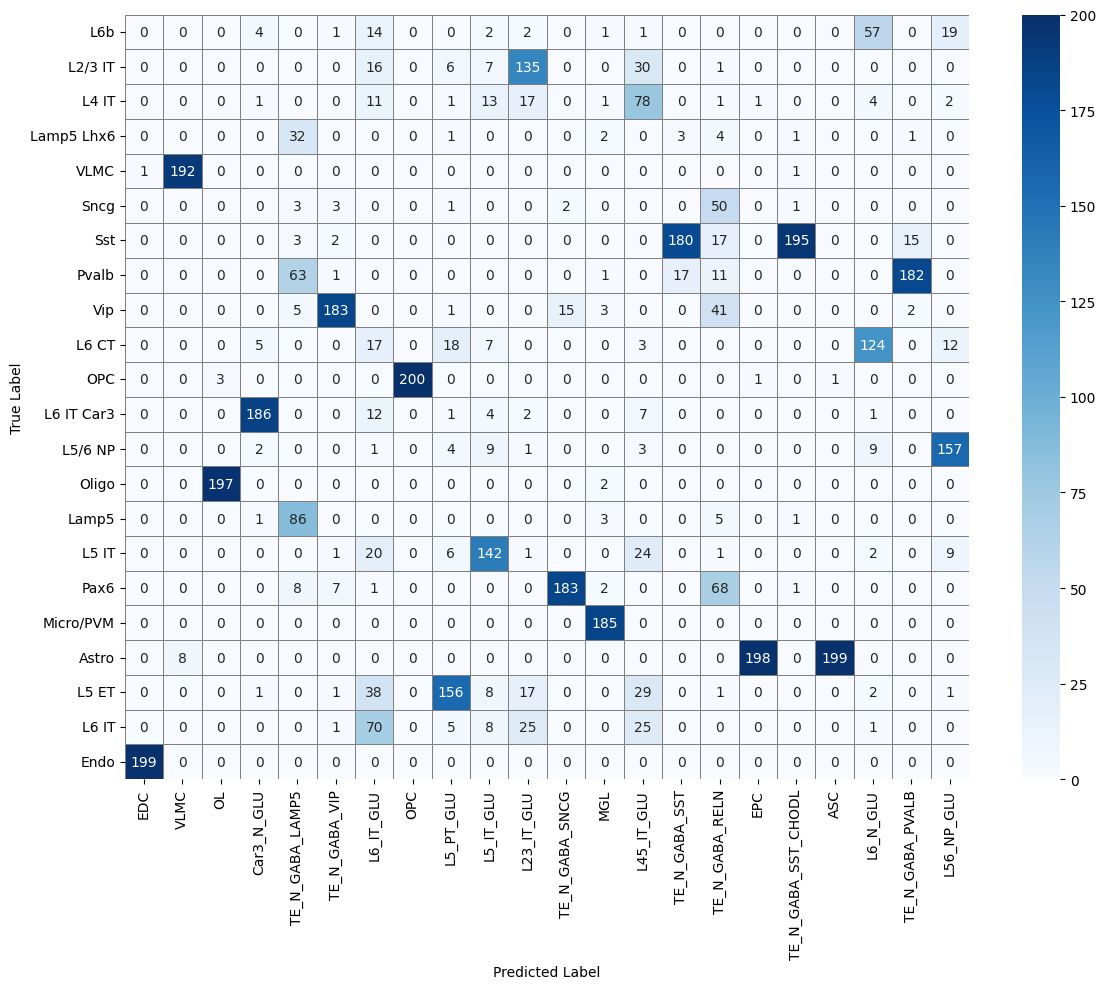

In [38]:
predict_class_names = rmge.evaluate()
sub_merged_data2.obs['predict']=predict_class_names
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 获取数据
true_labels = sub_merged_data2.obs['SubClass']
pred_labels = sub_merged_data2.obs['predict']

# 计算混淆矩阵
cm = confusion_matrix(true_labels, pred_labels)

# 创建标签列表（包含所有出现的类别）
classes = sorted(set(true_labels) | set(pred_labels))

# 转置混淆矩阵，使 true label 为列，pred label 为行
cm_df = pd.DataFrame(cm.T, index=classes, columns=classes)
cm_df = cm_df[list(set(true_labels))].loc[list(set(pred_labels))]
plt.figure(figsize=(12, 10))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, linecolor='gray')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()